In [1]:
# cell 1 : initialize shared experiment environment
from __future__ import annotations

import importlib.util
import json
import subprocess
import sys
from pathlib import Path

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
}

missing = [pkg for module, pkg in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

def resolve_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    return start

REPO_ROOT = resolve_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from policy.importance import NetworkState, build_importance_features

from tcp_batching_core import (
    DEFAULT_SEED,
    FIXED_BATCH_GRID,
    FIXED_FLUSH_GRID_MS,
    PolicyConfig,
    StaticFileConfig,
    TransportConfig,
    VideoTraceConfig,
    build_policy_features,
    fixed_sweep,
    generate_workload,
    pick_oracle,
    run_simulation,
    scenario_id,
    score_candidate_row,
)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
np.random.seed(DEFAULT_SEED)

OUTPUT_DIR = REPO_ROOT / "output" / "jupyter-notebook"
ASSET_DIR = OUTPUT_DIR / "assets"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ASSET_DIR.mkdir(parents=True, exist_ok=True)
TRACE_PATH = REPO_ROOT / "data" / "video-traces" / "bbb_720p_trace.csv"

def finalize_figure(fig) -> None:
    try:
        from IPython import get_ipython
        shell = get_ipython()
    except Exception:
        shell = None
    if shell is not None and shell.__class__.__name__ == "ZMQInteractiveShell":
        plt.show()
    else:
        plt.close(fig)

print(json.dumps({
    "python": sys.version.split()[0],
    "cli_hint": "py -3.9 -m jupyterlab",
    "repo_root": str(REPO_ROOT),
    "trace_path": str(TRACE_PATH),
    "output_dir": str(OUTPUT_DIR),
}, indent=2))

{
  "python": "3.9.13",
  "cli_hint": "py -3.9 -m jupyterlab",
  "repo_root": "C:\\git\\network",
  "trace_path": "C:\\git\\network\\data\\video-traces\\bbb_720p_trace.csv",
  "output_dir": "C:\\git\\network\\output\\jupyter-notebook"
}


## Experiment Scope

- Workloads: `static_file`, `video_stream_trace`
- Shared transport simulator implementation: `tcp_batching_core.py`
- Evaluation lens:
  - `static_file` is a transport-efficiency baseline, not the research objective.
  - `video_stream_trace` is the main workload for content-importance-aware adaptive transport.
- Core metrics:
  - Network: `latency_mean_ms`, `latency_p95_ms`, `throughput_mbps`, `goodput_bytes`, `flush_count`
  - Video utility: `deadline_miss_ms_sum`, `late_frame_ratio`, `keyframe_late_ratio`, `decodable_gop_ratio`, `useful_goodput_bytes`
- Success target:
  - `static_file` should reward batching efficiency.
  - `video_stream_trace` should reveal when frame-aware flushing protects useful playback.


In [2]:
# cell 2 : define scenarios and baseline policies
assert TRACE_PATH.exists(), f"Missing trace CSV: {TRACE_PATH}"
trace_df = pd.read_csv(TRACE_PATH)
assert trace_df["pts_ms"].is_monotonic_increasing
assert set(trace_df["frame_type"].unique()) <= {"I", "P", "B"}

def make_static(chunk_size: int, rtt_ms: float, bandwidth_mbps: float, delayed_ack_ms: float):
    return (
        StaticFileConfig(file_size_bytes=16 * 1024 * 1024, chunk_size_bytes=chunk_size),
        TransportConfig(rtt_ms=rtt_ms, bandwidth_mbps=bandwidth_mbps, delayed_ack_ms=delayed_ack_ms),
    )

def make_video(playback_buffer_ms: float, rtt_ms: float, bandwidth_mbps: float, delayed_ack_ms: float):
    return (
        VideoTraceConfig(trace_csv_path=TRACE_PATH, playback_buffer_ms=playback_buffer_ms),
        TransportConfig(rtt_ms=rtt_ms, bandwidth_mbps=bandwidth_mbps, delayed_ack_ms=delayed_ack_ms),
    )

STATIC_SCENARIOS = [
    make_static(chunk_size, rtt_ms, bandwidth_mbps, delayed_ack_ms)
    for chunk_size in [1024, 4096, 16384]
    for rtt_ms in [10, 50]
    for bandwidth_mbps in [5, 20]
    for delayed_ack_ms in [10, 40]
]
VIDEO_SCENARIOS = [
    make_video(playback_buffer_ms, rtt_ms, bandwidth_mbps, delayed_ack_ms)
    for playback_buffer_ms in [33, 50]
    for rtt_ms in [10, 50]
    for bandwidth_mbps in [5, 20]
    for delayed_ack_ms in [10, 40]
]
SCENARIOS = STATIC_SCENARIOS + VIDEO_SCENARIOS
SCENARIO_LOOKUP = {
    scenario_id(workload_cfg, transport_cfg): (workload_cfg, transport_cfg)
    for workload_cfg, transport_cfg in SCENARIOS
}

REFERENCE_SCENARIOS = {
    "static_reference": make_static(4096, 50, 20, 40),
    "video_reference": make_video(50, 10, 5, 40),
}

BASELINE_POLICIES = {
    "immediate": PolicyConfig("immediate"),
    "fixed_size_8192": PolicyConfig("fixed_size", batch_bytes=8192),
    "fixed_time_10ms": PolicyConfig("fixed_time", flush_interval_ms=10.0),
    "fixed_hybrid_8192_10ms": PolicyConfig("fixed_hybrid", batch_bytes=8192, flush_interval_ms=10.0),
    "heuristic_frame_aware": PolicyConfig("heuristic_frame_aware"),
}

scenario_overview = pd.DataFrame(
    [
        {
            "label": label,
            "scenario_id": scenario_id(workload_cfg, transport_cfg),
            "workload_kind": "static_file" if isinstance(workload_cfg, StaticFileConfig) else "video_stream_trace",
            "transport_rtt_ms": transport_cfg.rtt_ms,
            "transport_bandwidth_mbps": transport_cfg.bandwidth_mbps,
            "transport_delayed_ack_ms": transport_cfg.delayed_ack_ms,
            "extra": getattr(workload_cfg, "chunk_size_bytes", getattr(workload_cfg, "playback_buffer_ms", None)),
        }
        for label, (workload_cfg, transport_cfg) in REFERENCE_SCENARIOS.items()
    ]
)
scenario_overview

,label,scenario_id,workload_kind,transport_rtt_ms,transport_bandwidth_mbps,transport_delayed_ack_ms,extra
0,static_reference,static_16777216_4096_50_20_40,static_file,50,20,40,4096
1,video_reference,video_bbb_720p_trace_50_1_10_5_40,video_stream_trace,10,5,40,50


In [3]:
# cell 3 : sweep fixed baselines and train adaptive regressor
sweep_df = fixed_sweep(SCENARIOS)
scored_sweep_df, oracle_df, score_bounds = pick_oracle(sweep_df)

scenario_rows = []
for workload_cfg, transport_cfg in SCENARIOS:
    scenario_key = scenario_id(workload_cfg, transport_cfg)
    features = build_policy_features(workload_cfg, transport_cfg)
    scenario_rows.append({
        **features,
        "scenario_id": scenario_key,
        "workload_kind": features["workload_kind"],
    })

scenario_frame = pd.DataFrame(scenario_rows)
train_df = scenario_frame.merge(
    oracle_df[["scenario_id", "batch_bytes", "flush_interval_ms", "objective_score"]],
    on="scenario_id",
    how="left",
)
feature_frame = pd.get_dummies(train_df.drop(columns=["scenario_id", "batch_bytes", "flush_interval_ms", "objective_score"]), dummy_na=True).fillna(0.0)

train_ids, holdout_ids = train_test_split(
    train_df["scenario_id"],
    test_size=0.30,
    random_state=DEFAULT_SEED,
    stratify=train_df["workload_kind"],
)
train_mask = train_df["scenario_id"].isin(train_ids)
holdout_mask = train_df["scenario_id"].isin(holdout_ids)

batch_model = RandomForestRegressor(n_estimators=200, random_state=DEFAULT_SEED)
flush_model = RandomForestRegressor(n_estimators=200, random_state=DEFAULT_SEED + 1)
batch_model.fit(feature_frame.loc[train_mask], train_df.loc[train_mask, "batch_bytes"])
flush_model.fit(feature_frame.loc[train_mask], train_df.loc[train_mask, "flush_interval_ms"])

def to_ml_policy(feature_row: pd.DataFrame) -> PolicyConfig:
    pred_batch = float(batch_model.predict(feature_row)[0])
    pred_flush = float(flush_model.predict(feature_row)[0])
    return PolicyConfig(
        "ml_regression_adaptive",
        batch_bytes=int(max(1, min(FIXED_BATCH_GRID, key=lambda item: abs(item - pred_batch)))),
        flush_interval_ms=float(max(0.0, min(FIXED_FLUSH_GRID_MS, key=lambda item: abs(item - pred_flush)))),
    )

ml_rows = []
for _, row in train_df.loc[holdout_mask].iterrows():
    scenario_key = row["scenario_id"]
    workload_cfg, transport_cfg = SCENARIO_LOOKUP[scenario_key]
    row_features = feature_frame.loc[[row.name]]
    ml_policy = to_ml_policy(row_features)
    ml_result = run_simulation(workload_cfg, transport_cfg, ml_policy)
    heuristic_result = run_simulation(workload_cfg, transport_cfg, PolicyConfig("heuristic_frame_aware"))
    oracle_row = oracle_df.loc[oracle_df["scenario_id"] == scenario_key].iloc[0]
    bounds = score_bounds[scenario_key]
    reference_scores = scored_sweep_df.loc[scored_sweep_df["scenario_id"] == scenario_key, "objective_score"]

    for comparison, result in [
        ("ml_regression_adaptive", ml_result),
        ("heuristic_frame_aware", heuristic_result),
    ]:
        candidate_score = score_candidate_row(result, bounds)
        ml_rows.append({
            **result,
            "comparison": comparison,
            "oracle_score": float(oracle_row["objective_score"]),
            "candidate_score": candidate_score,
            "oracle_score_gap": float(oracle_row["objective_score"]) - candidate_score,
            "candidate_rank_vs_fixed_sweep": int(1 + (reference_scores > candidate_score).sum()),
        })

ml_eval_df = pd.DataFrame(ml_rows)

def reference_policy_rows() -> pd.DataFrame:
    rows = []
    for label, (workload_cfg, transport_cfg) in REFERENCE_SCENARIOS.items():
        reference_features = pd.get_dummies(pd.DataFrame([build_policy_features(workload_cfg, transport_cfg)]), dummy_na=True).fillna(0.0)
        aligned = reference_features.reindex(columns=feature_frame.columns, fill_value=0.0)
        ml_policy = to_ml_policy(aligned)
        policy_map = dict(BASELINE_POLICIES)
        policy_map["ml_regression_adaptive"] = ml_policy
        for comparison, policy_cfg in policy_map.items():
            result = run_simulation(workload_cfg, transport_cfg, policy_cfg)
            scenario_key = result["scenario_id"]
            candidate_score = score_candidate_row(result, score_bounds[scenario_key])
            oracle_score = float(oracle_df.loc[oracle_df["scenario_id"] == scenario_key, "objective_score"].iloc[0])
            rows.append({
                **result,
                "reference_label": label,
                "comparison": comparison,
                "candidate_score": candidate_score,
                "oracle_score_gap": oracle_score - candidate_score,
            })
    return pd.DataFrame(rows)

reference_results = reference_policy_rows()

summary_columns = [
    "reference_label",
    "workload_kind",
    "comparison",
    "latency_mean_ms",
    "latency_p95_ms",
    "throughput_mbps",
    "goodput_bytes",
    "flush_count",
    "late_frame_ratio",
    "keyframe_late_ratio",
    "decodable_gop_ratio",
    "useful_goodput_bytes",
    "oracle_score_gap",
]
reference_summary = reference_results[summary_columns].sort_values(["reference_label", "comparison"]).reset_index(drop=True)
reference_summary.head(12)

,reference_label,workload_kind,comparison,latency_mean_ms,latency_p95_ms,throughput_mbps,goodput_bytes,flush_count,late_frame_ratio,keyframe_late_ratio,decodable_gop_ratio,useful_goodput_bytes,oracle_score_gap
0,static_reference,static_file,fixed_hybrid_8192_10ms,28867.256600,54832.16530,2.317658,16777216.0,2048,0.000000,0.0,0.0,16777216.0,0.515007
1,static_reference,static_file,fixed_size_8192,28867.256600,54832.16530,2.317658,16777216.0,2048,0.000000,0.0,0.0,16777216.0,0.515007
2,static_reference,static_file,fixed_time_10ms,3693.563744,6868.16250,18.523300,16777216.0,21,0.000000,0.0,0.0,16777216.0,0.000000
3,static_reference,static_file,heuristic_frame_aware,6479.425400,12302.02610,10.236535,16777216.0,256,0.000000,0.0,0.0,16777216.0,0.000000
4,static_reference,static_file,immediate,54466.387400,103462.16150,1.230104,16777216.0,4096,0.000000,0.0,0.0,16777216.0,0.750000
5,static_reference,static_file,ml_regression_adaptive,6479.425400,12302.02610,10.236535,16777216.0,256,0.000000,0.0,0.0,16777216.0,0.000000
6,video_reference,video_stream_trace,fixed_hybrid_8192_10ms,22.217443,26.96760,0.773177,965199.0,300,0.016667,1.0,0.0,796986.0,0.001882
7,video_reference,video_stream_trace,fixed_size_8192,116.819975,200.27440,0.773535,965199.0,52,0.663333,1.0,0.0,604836.0,0.500000
8,video_reference,video_stream_trace,fixed_time_10ms,24.017443,36.01064,0.773177,965199.0,300,0.023333,1.0,0.0,795658.0,0.284365
9,video_reference,video_stream_trace,heuristic_frame_aware,26.924110,26.11248,0.773332,965199.0,300,0.016667,1.0,0.0,796986.0,0.000200


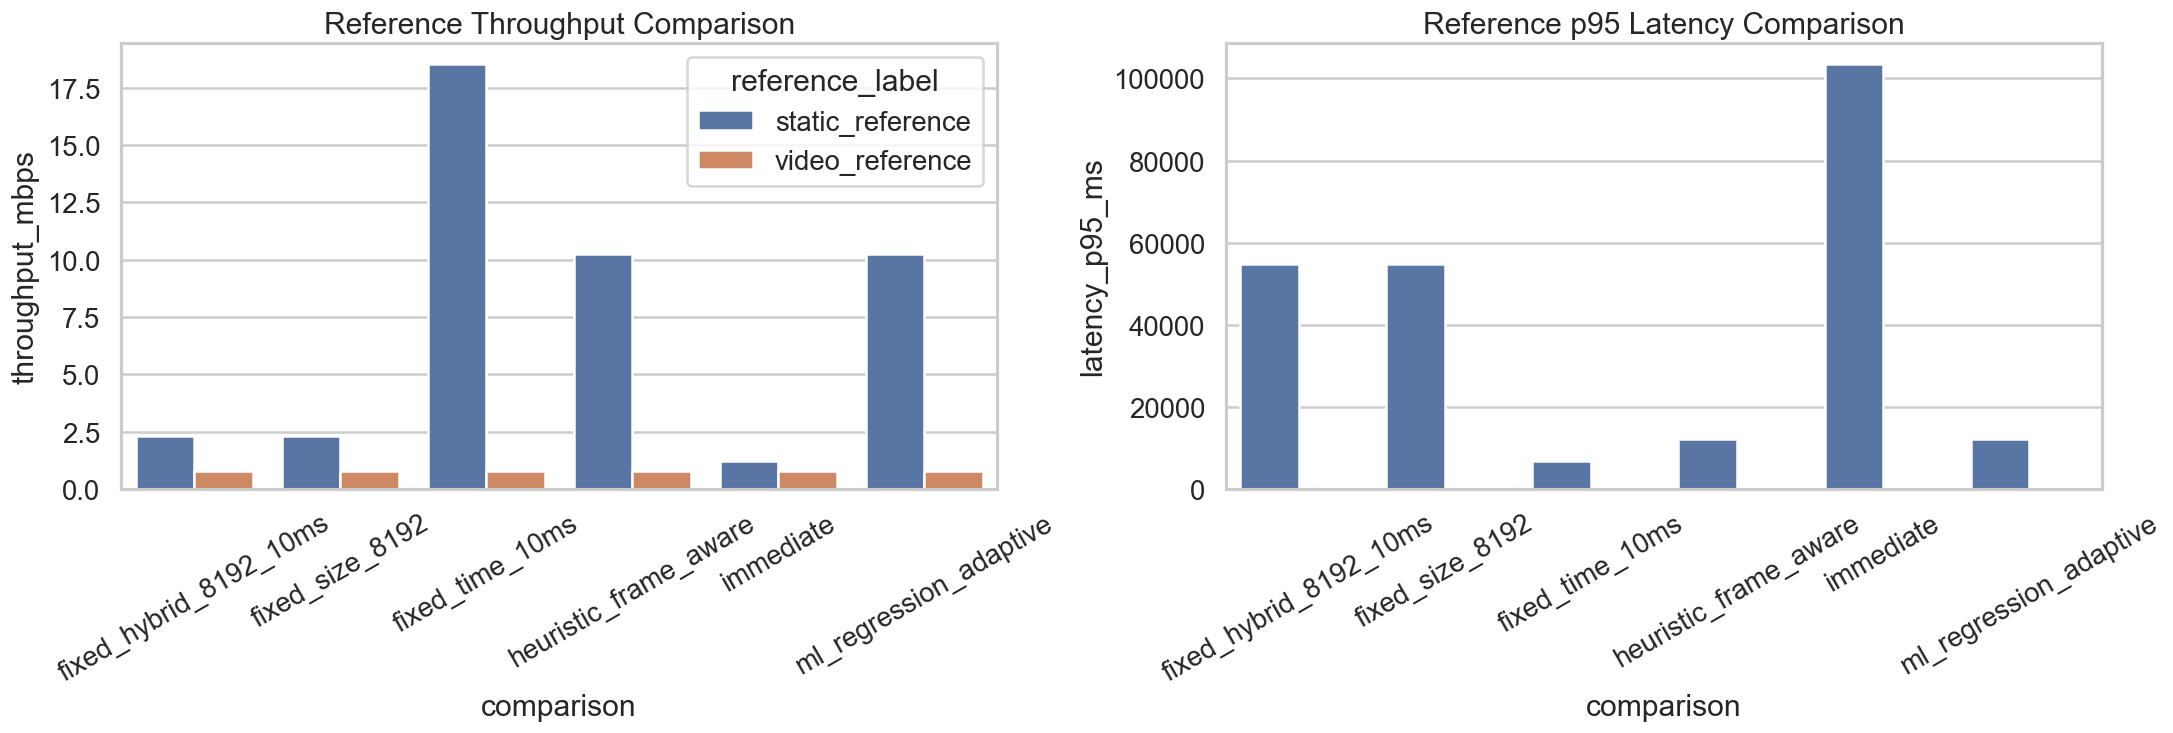

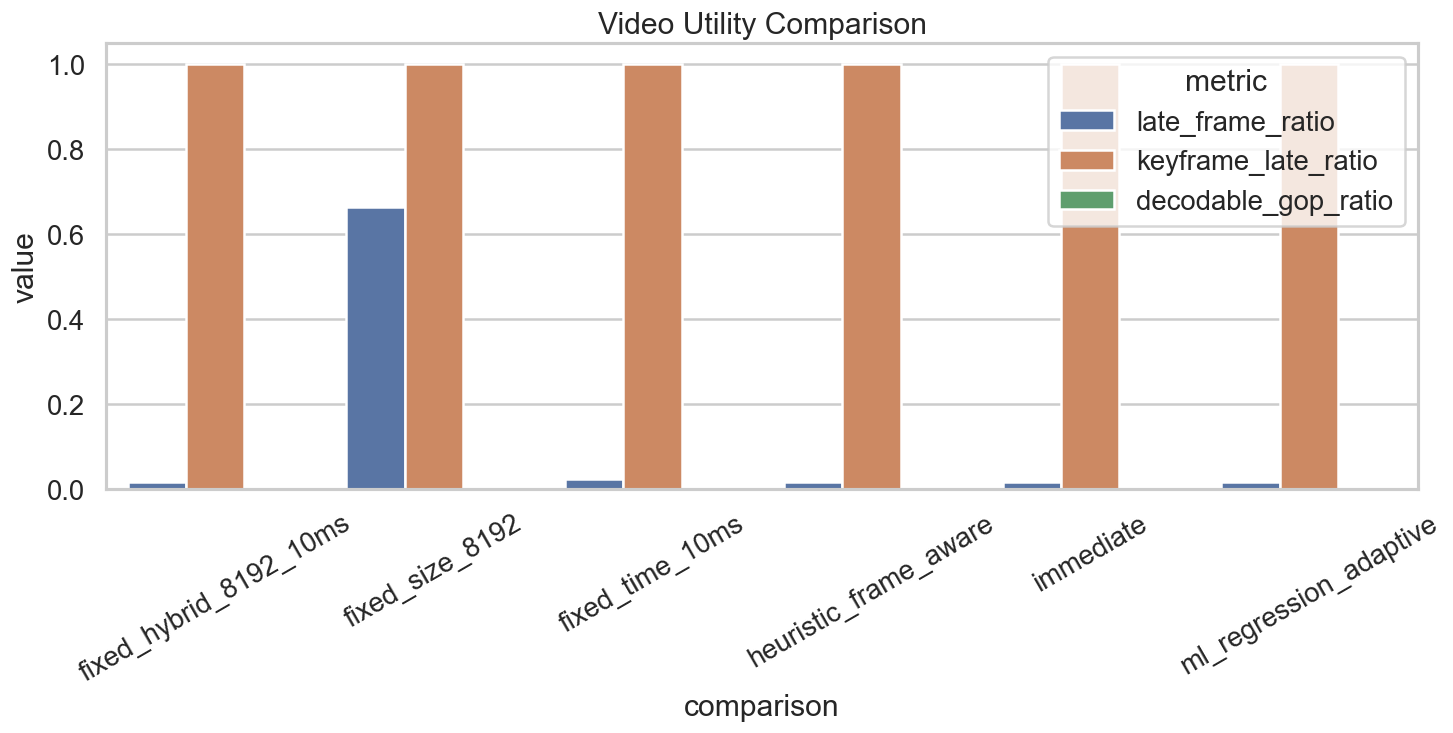

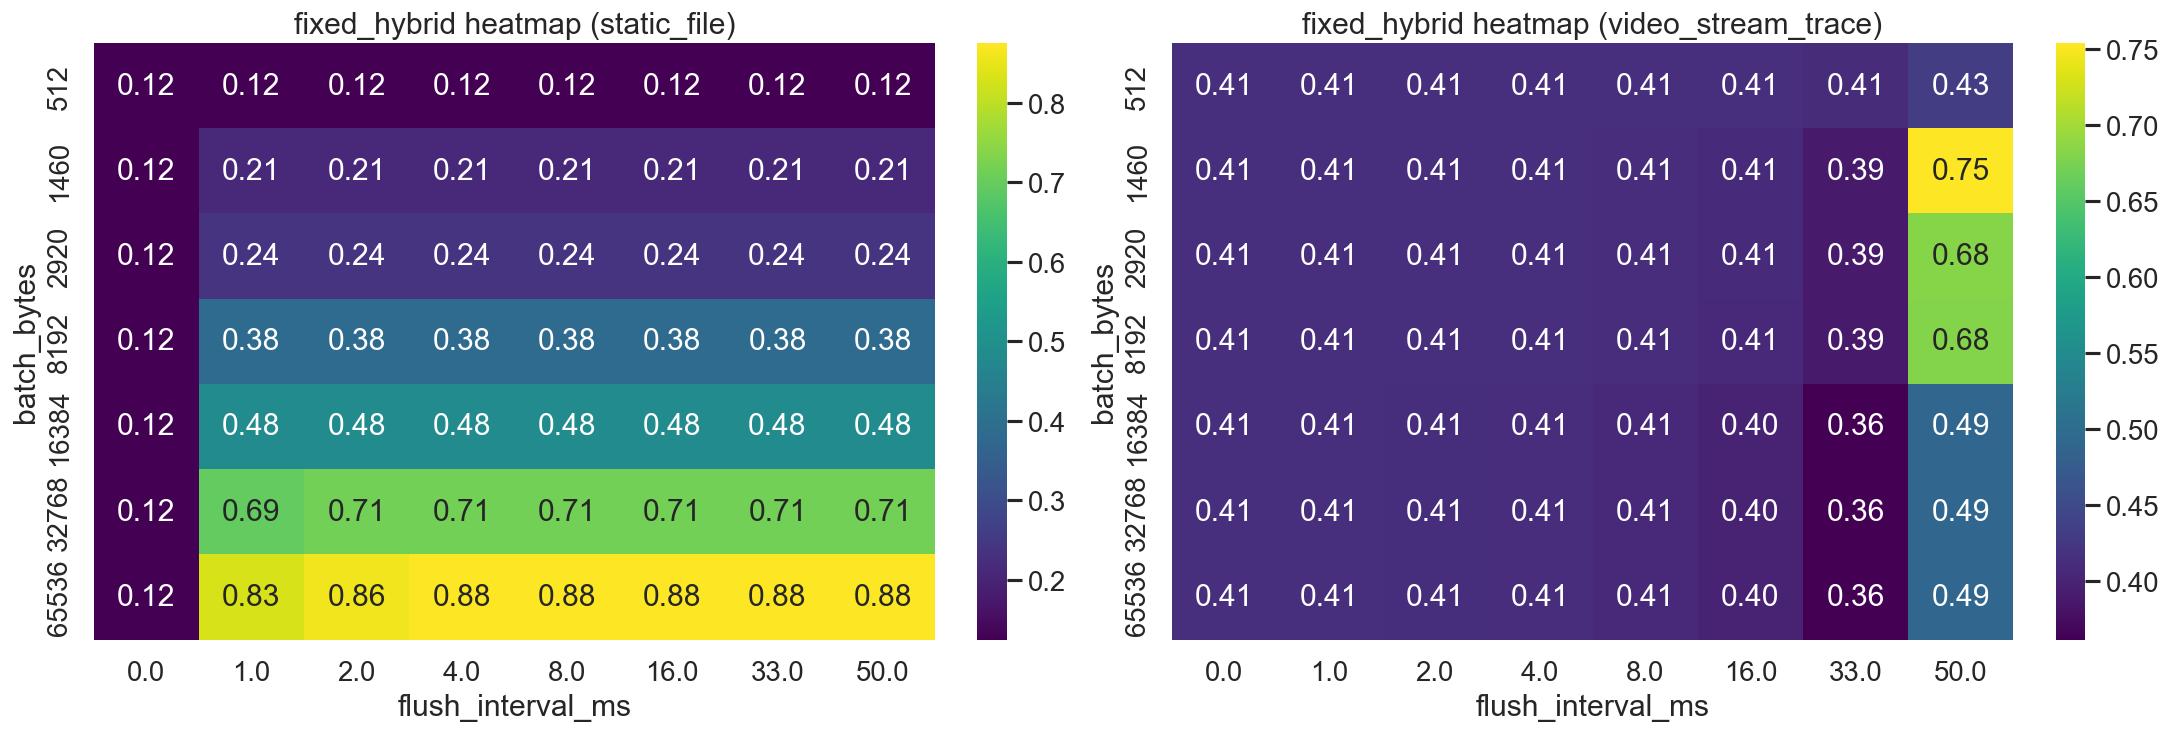

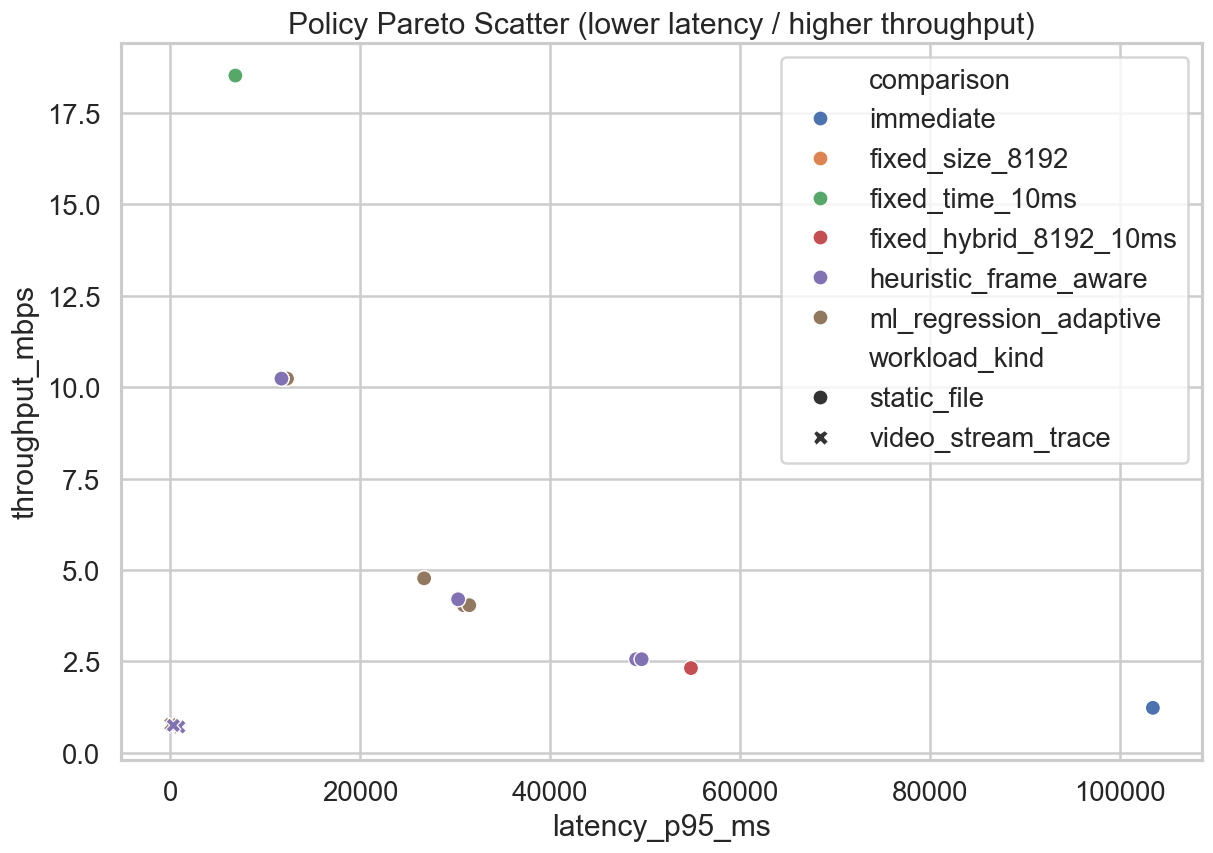

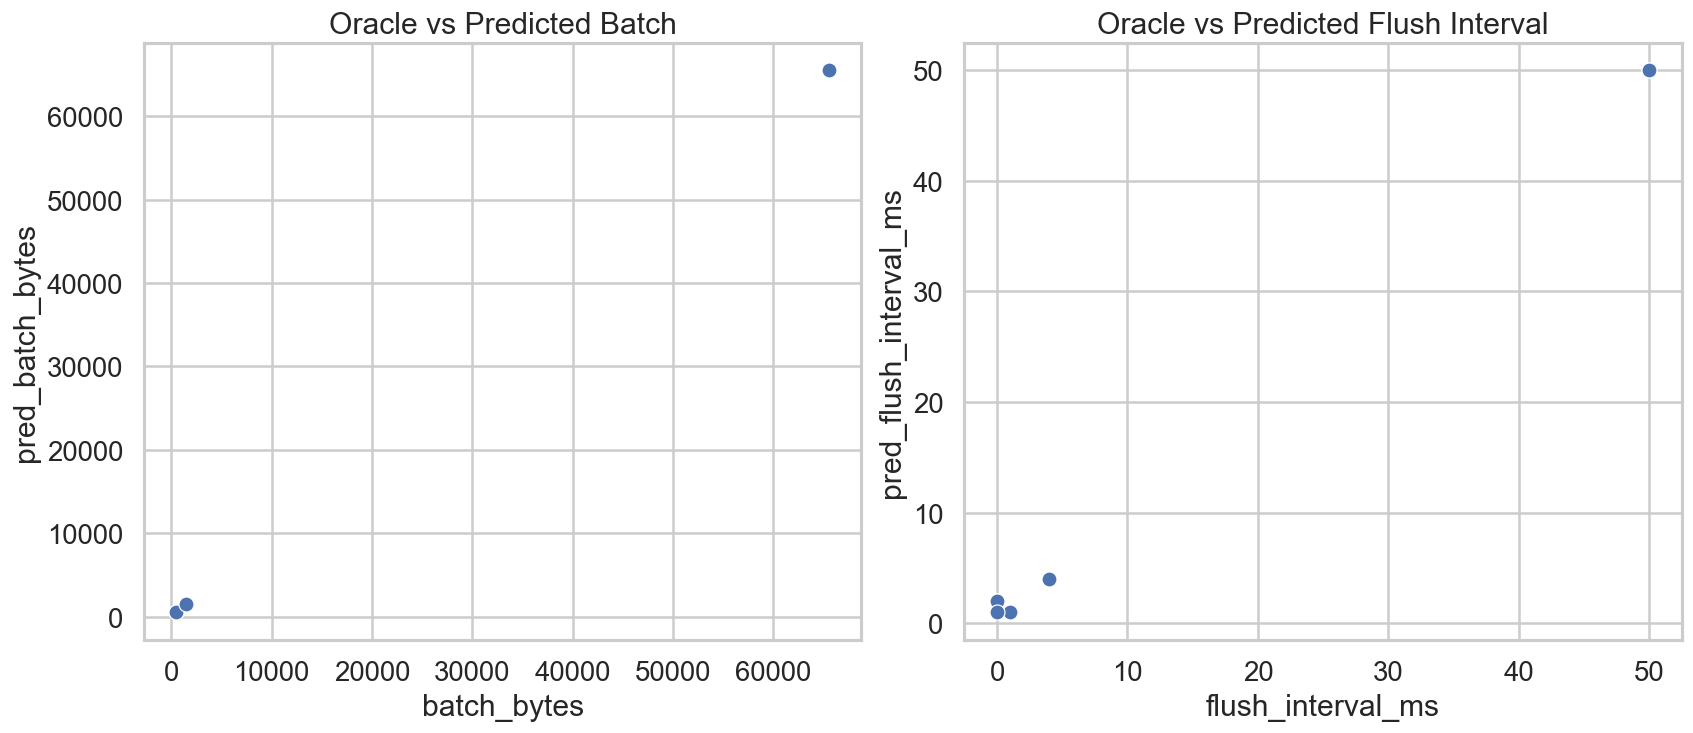

saved:
- C:\git\network\output\jupyter-notebook\assets\reference_policy_overview.png
- C:\git\network\output\jupyter-notebook\assets\video_utility_comparison.png
- C:\git\network\output\jupyter-notebook\assets\fixed_batch_heatmap.png
- C:\git\network\output\jupyter-notebook\assets\policy_pareto_scatter.png
- C:\git\network\output\jupyter-notebook\assets\oracle_vs_prediction_scatter.png
- C:\git\network\output\jupyter-notebook\assets\reference_summary.csv
- C:\git\network\output\jupyter-notebook\assets\fixed_sweep_results.csv
- C:\git\network\output\jupyter-notebook\assets\oracle_selection.csv
- C:\git\network\output\jupyter-notebook\assets\ml_eval_results.csv

holdout summary:
comparison
heuristic_frame_aware     0.3506
ml_regression_adaptive    0.0000


In [4]:
# cell 4 : render comparison plots and save artifacts
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
sns.barplot(data=reference_summary, x="comparison", y="throughput_mbps", hue="reference_label", ax=axes[0])
axes[0].set_title("Reference Throughput Comparison")
axes[0].tick_params(axis="x", rotation=30)
sns.barplot(data=reference_summary, x="comparison", y="latency_p95_ms", hue="reference_label", ax=axes[1])
axes[1].set_title("Reference p95 Latency Comparison")
axes[1].tick_params(axis="x", rotation=30)
if axes[1].legend_ is not None:
    axes[1].legend_.remove()
reference_path = ASSET_DIR / "reference_policy_overview.png"
fig.savefig(reference_path, bbox_inches="tight")
finalize_figure(fig)

video_reference = reference_summary[reference_summary["workload_kind"] == "video_stream_trace"].copy()
utility_source = video_reference.melt(
    id_vars=["comparison"],
    value_vars=["late_frame_ratio", "keyframe_late_ratio", "decodable_gop_ratio"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
sns.barplot(data=utility_source, x="comparison", y="value", hue="metric", ax=ax)
ax.set_title("Video Utility Comparison")
ax.tick_params(axis="x", rotation=30)
utility_path = ASSET_DIR / "video_utility_comparison.png"
fig.savefig(utility_path, bbox_inches="tight")
finalize_figure(fig)

heatmap_source = scored_sweep_df.groupby(["workload_kind", "batch_bytes", "flush_interval_ms"], as_index=False)["objective_score"].mean()
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
for ax, workload_kind in zip(axes, ["static_file", "video_stream_trace"]):
    pivot = heatmap_source[heatmap_source["workload_kind"] == workload_kind].pivot(
        index="batch_bytes",
        columns="flush_interval_ms",
        values="objective_score",
    )
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis", ax=ax)
    ax.set_title(f"fixed_hybrid heatmap ({workload_kind})")
heatmap_path = ASSET_DIR / "fixed_batch_heatmap.png"
fig.savefig(heatmap_path, bbox_inches="tight")
finalize_figure(fig)

pareto_df = pd.concat(
    [
        reference_results[["comparison", "workload_kind", "latency_p95_ms", "throughput_mbps"]],
        ml_eval_df[["comparison", "workload_kind", "latency_p95_ms", "throughput_mbps"]],
    ],
    ignore_index=True,
)
fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
sns.scatterplot(
    data=pareto_df,
    x="latency_p95_ms",
    y="throughput_mbps",
    hue="comparison",
    style="workload_kind",
    ax=ax,
)
ax.set_title("Policy Pareto Scatter (lower latency / higher throughput)")
pareto_path = ASSET_DIR / "policy_pareto_scatter.png"
fig.savefig(pareto_path, bbox_inches="tight")
finalize_figure(fig)

holdout_oracle = train_df.loc[holdout_mask, ["scenario_id", "batch_bytes", "flush_interval_ms"]].copy()
holdout_predictions = []
for _, row in train_df.loc[holdout_mask].iterrows():
    pred = to_ml_policy(feature_frame.loc[[row.name]])
    holdout_predictions.append({
        "scenario_id": row["scenario_id"],
        "pred_batch_bytes": pred.batch_bytes,
        "pred_flush_interval_ms": pred.flush_interval_ms,
    })
prediction_df = holdout_oracle.merge(pd.DataFrame(holdout_predictions), on="scenario_id", how="left")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
sns.scatterplot(data=prediction_df, x="batch_bytes", y="pred_batch_bytes", ax=axes[0])
axes[0].set_title("Oracle vs Predicted Batch")
sns.scatterplot(data=prediction_df, x="flush_interval_ms", y="pred_flush_interval_ms", ax=axes[1])
axes[1].set_title("Oracle vs Predicted Flush Interval")
oracle_scatter_path = ASSET_DIR / "oracle_vs_prediction_scatter.png"
fig.savefig(oracle_scatter_path, bbox_inches="tight")
finalize_figure(fig)

reference_summary.to_csv(ASSET_DIR / "reference_summary.csv", index=False)
scored_sweep_df.to_csv(ASSET_DIR / "fixed_sweep_results.csv", index=False)
oracle_df.to_csv(ASSET_DIR / "oracle_selection.csv", index=False)
ml_eval_df.to_csv(ASSET_DIR / "ml_eval_results.csv", index=False)

print("saved:")
for path in [
    reference_path,
    utility_path,
    heatmap_path,
    pareto_path,
    oracle_scatter_path,
    ASSET_DIR / "reference_summary.csv",
    ASSET_DIR / "fixed_sweep_results.csv",
    ASSET_DIR / "oracle_selection.csv",
    ASSET_DIR / "ml_eval_results.csv",
]:
    print(f"- {path}")

print()
print("holdout summary:")
print(
    ml_eval_df.groupby("comparison")["oracle_score_gap"].mean().round(4).to_string()
)

## Validation Notes

- The notebook treats the simulator as shared infrastructure instead of duplicating logic in-place.
- Fixed batching policies remain transport-layer baselines, while the main analytical focus stays on content-aware adaptive transport.
- `ml_regression_adaptive` is evaluated only after oracle labels are regenerated from the `fixed_hybrid` sweep.


## Notebook Artifact Review

- Load the primary CSV and PNG artifacts generated by this notebook for quick verification.
- If an artifact is missing, print its expected path so the relevant generation cell can be rerun.


repo_root: C:\git\network
assets_dir: C:\git\network\output\jupyter-notebook\assets


### reference_summary.csv

,reference_label,workload_kind,comparison,latency_mean_ms,latency_p95_ms,throughput_mbps,goodput_bytes,flush_count,late_frame_ratio,keyframe_late_ratio,decodable_gop_ratio,useful_goodput_bytes,oracle_score_gap
0,static_reference,static_file,fixed_hybrid_8192_10ms,28867.256600,54832.16530,2.317658,16777216.0,2048,0.000000,0.0,0.0,16777216.0,0.515007
1,static_reference,static_file,fixed_size_8192,28867.256600,54832.16530,2.317658,16777216.0,2048,0.000000,0.0,0.0,16777216.0,0.515007
2,static_reference,static_file,fixed_time_10ms,3693.563744,6868.16250,18.523300,16777216.0,21,0.000000,0.0,0.0,16777216.0,0.000000
3,static_reference,static_file,heuristic_frame_aware,6479.425400,12302.02610,10.236535,16777216.0,256,0.000000,0.0,0.0,16777216.0,0.000000
4,static_reference,static_file,immediate,54466.387400,103462.16150,1.230104,16777216.0,4096,0.000000,0.0,0.0,16777216.0,0.750000
5,static_reference,static_file,ml_regression_adaptive,6479.425400,12302.02610,10.236535,16777216.0,256,0.000000,0.0,0.0,16777216.0,0.000000
6,video_reference,video_stream_trace,fixed_hybrid_8192_10ms,22.217443,26.96760,0.773177,965199.0,300,0.016667,1.0,0.0,796986.0,0.001882
7,video_reference,video_stream_trace,fixed_size_8192,116.819975,200.27440,0.773535,965199.0,52,0.663333,1.0,0.0,604836.0,0.500000
8,video_reference,video_stream_trace,fixed_time_10ms,24.017443,36.01064,0.773177,965199.0,300,0.023333,1.0,0.0,795658.0,0.284365
9,video_reference,video_stream_trace,heuristic_frame_aware,26.924110,26.11248,0.773332,965199.0,300,0.016667,1.0,0.0,796986.0,0.000200


### ml_eval_results.csv

,workload_kind,file_size_bytes,chunk_size_bytes,generation_gap_ms,rtt_ms,bandwidth_mbps,delayed_ack_ms,mss_bytes,nagle_penalty_factor,propagation_factor,...,playback_buffer_ms,loop_count,trace_name,mean_frame_bytes,p95_frame_bytes,frame_interval_ms,keyframe_interval_frames,i_ratio,p_ratio,b_ratio
0,static_file,16777216.0,1024.0,0.05,50.0,5.0,40.0,1460.0,0.25,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,static_file,16777216.0,1024.0,0.05,50.0,5.0,40.0,1460.0,0.25,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,static_file,16777216.0,1024.0,0.05,50.0,20.0,10.0,1460.0,0.25,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,static_file,16777216.0,1024.0,0.05,50.0,20.0,10.0,1460.0,0.25,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,static_file,16777216.0,1024.0,0.05,50.0,20.0,40.0,1460.0,0.25,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,static_file,16777216.0,1024.0,0.05,50.0,20.0,40.0,1460.0,0.25,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,static_file,16777216.0,4096.0,0.05,50.0,5.0,10.0,1460.0,0.25,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,static_file,16777216.0,4096.0,0.05,50.0,5.0,10.0,1460.0,0.25,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,static_file,16777216.0,4096.0,0.05,50.0,5.0,40.0,1460.0,0.25,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,static_file,16777216.0,4096.0,0.05,50.0,5.0,40.0,1460.0,0.25,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### oracle_selection.csv

,workload_kind,file_size_bytes,chunk_size_bytes,generation_gap_ms,rtt_ms,bandwidth_mbps,delayed_ack_ms,mss_bytes,nagle_penalty_factor,propagation_factor,...,b_ratio,throughput_mbps_score,goodput_bytes_score,latency_p95_ms_score,flush_count_score,objective_score,decodable_gop_ratio_score,late_frame_ratio_score,keyframe_late_ratio_score,useful_goodput_bytes_score
0,static_file,16777216.0,1024.0,0.05,10.0,20.0,10.0,1460.0,0.25,0.5,...,NaN,1.0,0.5,1.0,1.0,0.875,NaN,NaN,NaN,NaN
1,static_file,16777216.0,1024.0,0.05,10.0,20.0,40.0,1460.0,0.25,0.5,...,NaN,1.0,0.5,1.0,1.0,0.875,NaN,NaN,NaN,NaN
2,static_file,16777216.0,1024.0,0.05,10.0,5.0,10.0,1460.0,0.25,0.5,...,NaN,1.0,0.5,1.0,1.0,0.875,NaN,NaN,NaN,NaN
3,static_file,16777216.0,1024.0,0.05,10.0,5.0,40.0,1460.0,0.25,0.5,...,NaN,1.0,0.5,1.0,1.0,0.875,NaN,NaN,NaN,NaN
4,static_file,16777216.0,1024.0,0.05,50.0,20.0,10.0,1460.0,0.25,0.5,...,NaN,1.0,0.5,1.0,1.0,0.875,NaN,NaN,NaN,NaN
5,static_file,16777216.0,1024.0,0.05,50.0,20.0,40.0,1460.0,0.25,0.5,...,NaN,1.0,0.5,1.0,1.0,0.875,NaN,NaN,NaN,NaN
6,static_file,16777216.0,1024.0,0.05,50.0,5.0,10.0,1460.0,0.25,0.5,...,NaN,1.0,0.5,1.0,1.0,0.875,NaN,NaN,NaN,NaN
7,static_file,16777216.0,1024.0,0.05,50.0,5.0,40.0,1460.0,0.25,0.5,...,NaN,1.0,0.5,1.0,1.0,0.875,NaN,NaN,NaN,NaN
8,static_file,16777216.0,16384.0,0.05,10.0,20.0,10.0,1460.0,0.25,0.5,...,NaN,1.0,0.5,1.0,1.0,0.875,NaN,NaN,NaN,NaN
9,static_file,16777216.0,16384.0,0.05,10.0,20.0,40.0,1460.0,0.25,0.5,...,NaN,1.0,0.5,1.0,1.0,0.875,NaN,NaN,NaN,NaN


### reference_policy_overview.png

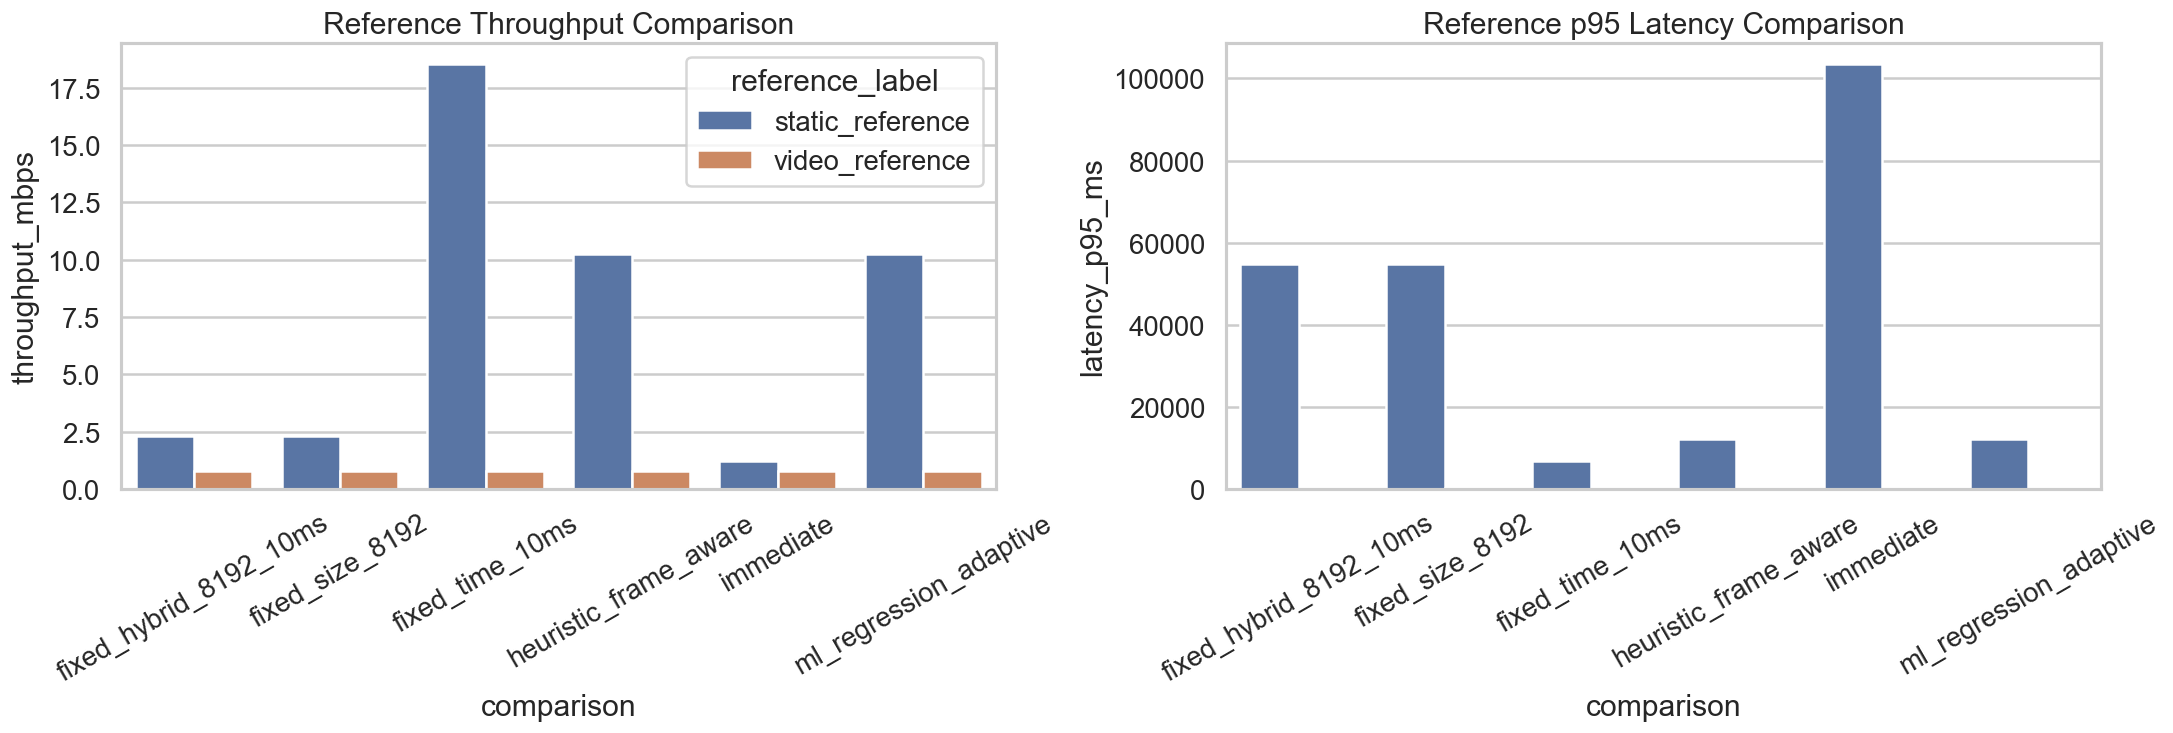

### video_utility_comparison.png

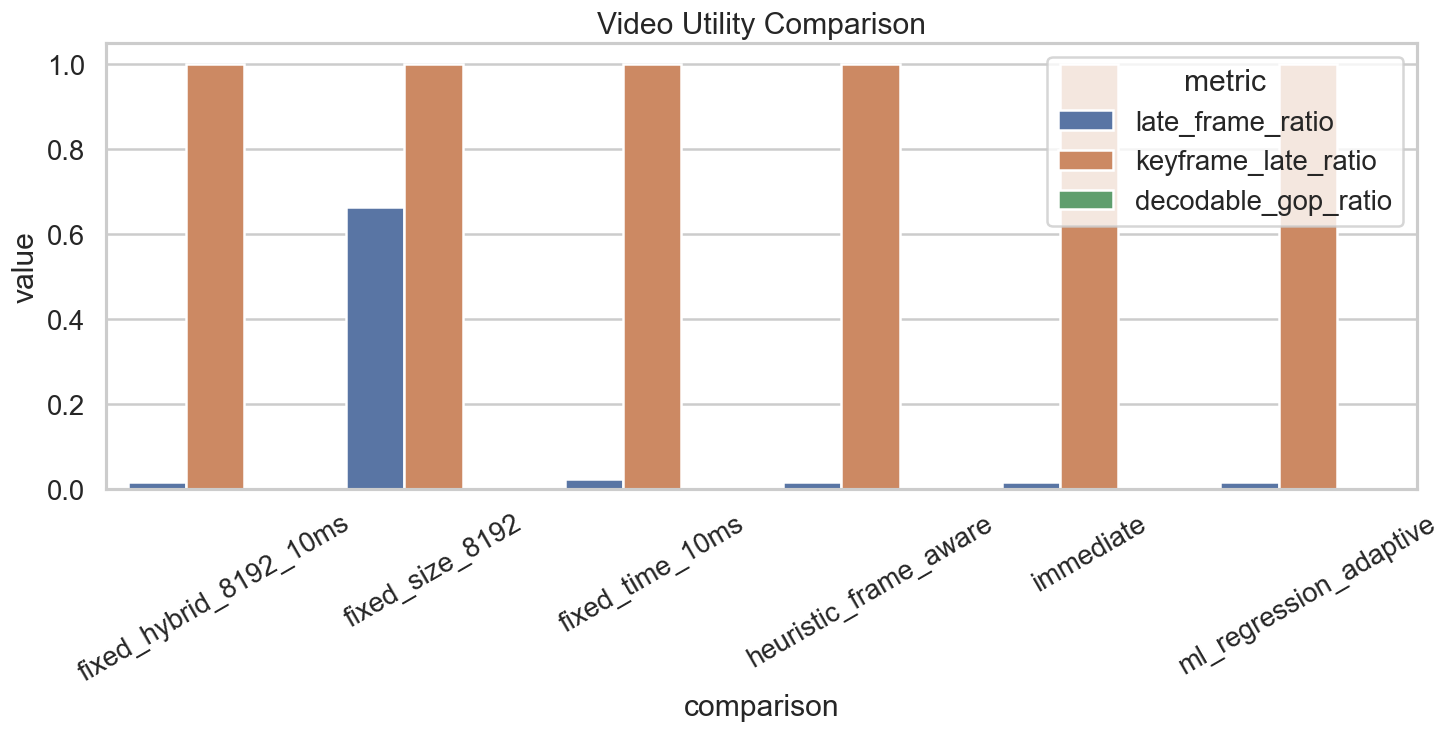

### fixed_batch_heatmap.png

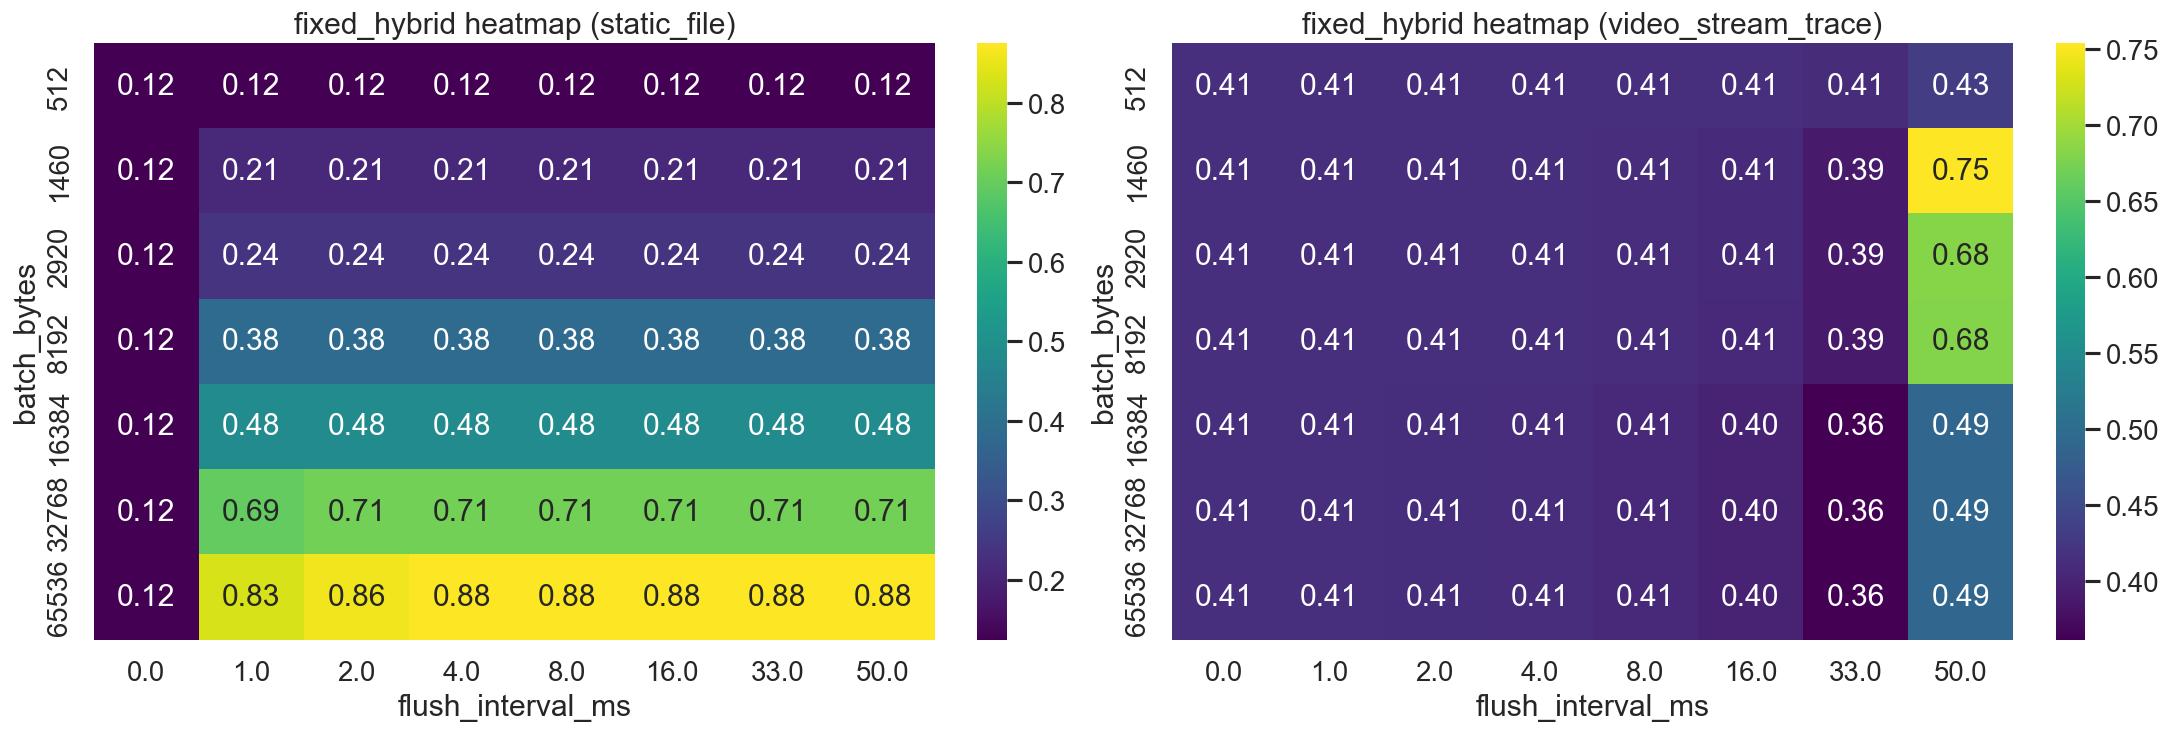

### policy_pareto_scatter.png

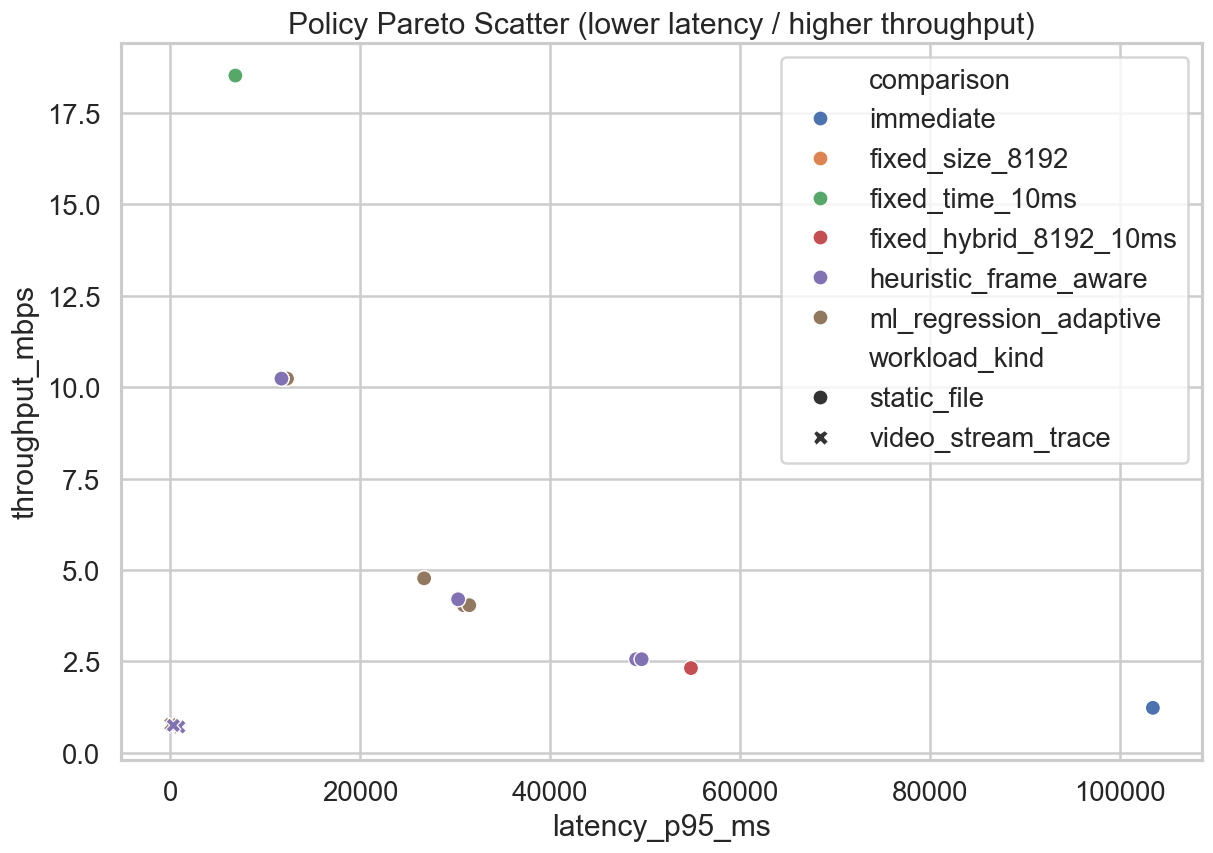

### oracle_vs_prediction_scatter.png

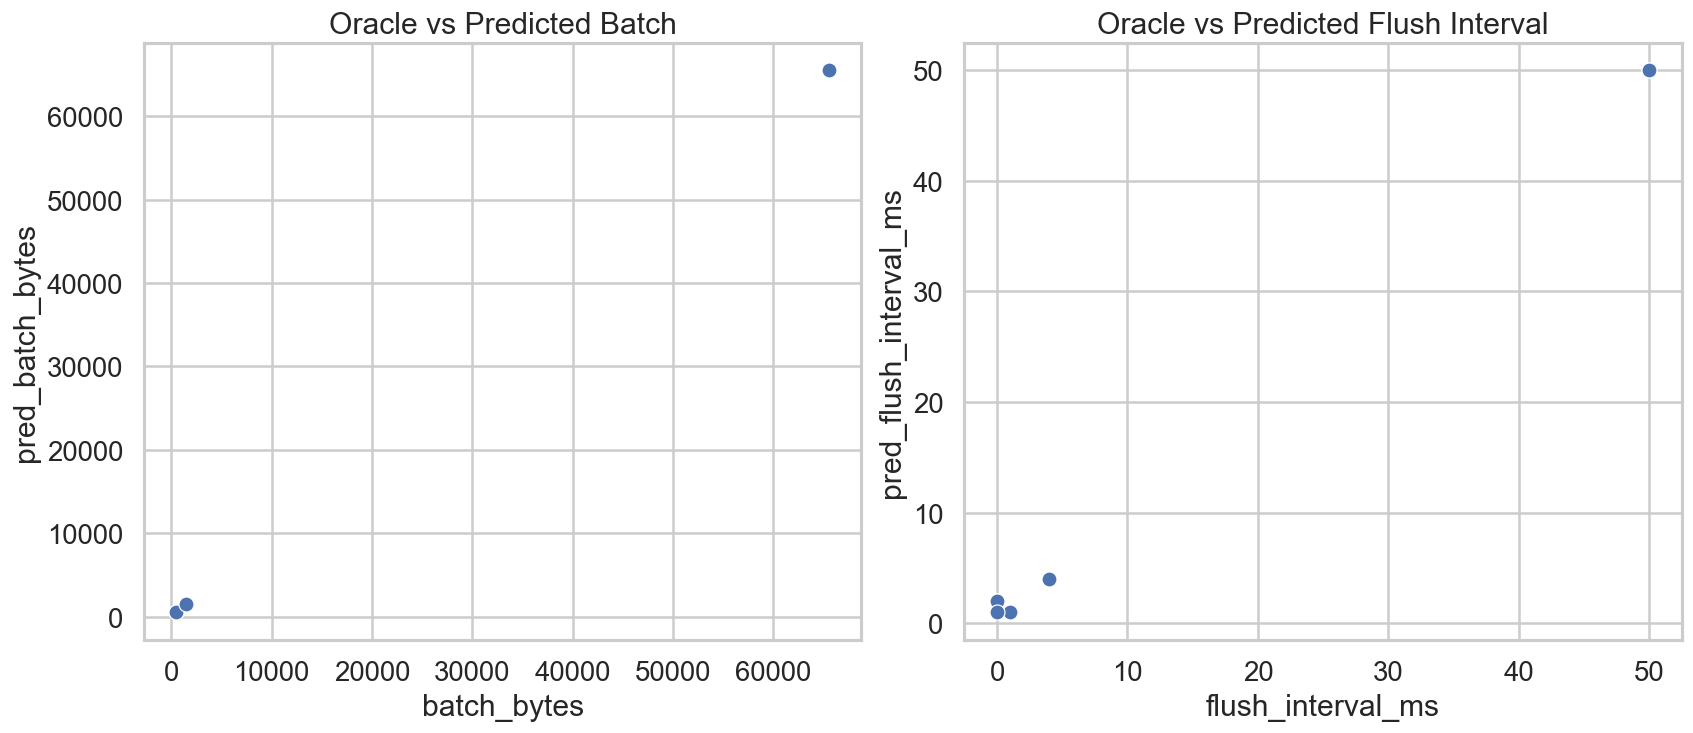

In [5]:
# cell 5 : review core CSV and image artifacts
from IPython.display import Image, Markdown, display

artifact_csvs = [
    ASSET_DIR / "reference_summary.csv",
    ASSET_DIR / "ml_eval_results.csv",
    ASSET_DIR / "oracle_selection.csv",
]
artifact_images = [
    ASSET_DIR / "reference_policy_overview.png",
    ASSET_DIR / "video_utility_comparison.png",
    ASSET_DIR / "fixed_batch_heatmap.png",
    ASSET_DIR / "policy_pareto_scatter.png",
    ASSET_DIR / "oracle_vs_prediction_scatter.png",
]

print(f"repo_root: {REPO_ROOT}")
print(f"assets_dir: {ASSET_DIR}")

for csv_path in artifact_csvs:
    if csv_path.exists():
        display(Markdown(f"### {csv_path.name}"))
        display(pd.read_csv(csv_path).head(10))
    else:
        print(f"missing: {csv_path}")

for image_path in artifact_images:
    if image_path.exists():
        display(Markdown(f"### {image_path.name}"))
        display(Image(filename=str(image_path)))
    else:
        print(f"missing: {image_path}")

In [6]:
# cell 6 : inspect QoE label summary by frame type
label_csv = REPO_ROOT / "data" / "video-traces" / "bbb_720p_delta_qoe_labels.csv"

if label_csv.exists():
    labels_df = pd.read_csv(label_csv)
    display(Markdown("### bbb_720p_delta_qoe_labels.csv (head)"))
    display(labels_df.head(10))

    display(Markdown("### frame_type vs delta_qoe_norm summary"))
    display(
        labels_df.groupby("frame_type", sort=False)["delta_qoe_norm"]
        .agg(["count", "mean", "median", "max"])
        .reset_index()
    )
else:
    print(f"missing: {label_csv}")
    print("run: py -3 scripts/build_delta_qoe_labels.py --trace data/video-traces/bbb_720p_trace.csv --output data/video-traces/bbb_720p_delta_qoe_labels.csv")

### bbb_720p_delta_qoe_labels.csv (head)

,event_idx,frame_type,key_frame,gop_id,payload_bytes,event_time_ms,display_deadline_ms,baseline_on_time,baseline_qoe,drop_qoe,delta_qoe,label_mode,delta_qoe_norm
0,0,I,1,0,77331,0.000,83.333,False,0.355867,0.054957,0.300910,delta_qoe_proxy_v1,1.000000
1,1,B,0,0,301,33.333,116.667,True,0.355867,0.354814,0.001052,delta_qoe_proxy_v1,0.003497
2,2,B,0,0,460,66.667,150.000,True,0.355867,0.354804,0.001062,delta_qoe_proxy_v1,0.003530
3,3,B,0,0,521,100.000,183.333,True,0.355867,0.354801,0.001066,delta_qoe_proxy_v1,0.003543
4,4,B,0,0,713,133.333,216.667,True,0.355867,0.354789,0.001078,delta_qoe_proxy_v1,0.003583
5,5,B,0,0,567,166.667,250.000,True,0.355867,0.354798,0.001069,delta_qoe_proxy_v1,0.003552
6,6,P,0,0,2133,200.000,283.333,True,0.355867,0.354700,0.001167,delta_qoe_proxy_v1,0.003879
7,7,B,0,0,407,233.333,316.667,True,0.355867,0.354808,0.001059,delta_qoe_proxy_v1,0.003519
8,8,B,0,0,602,266.667,350.000,True,0.355867,0.354796,0.001071,delta_qoe_proxy_v1,0.003559
9,9,B,0,0,698,300.000,383.333,True,0.355867,0.354790,0.001077,delta_qoe_proxy_v1,0.003580


### frame_type vs delta_qoe_norm summary

,frame_type,count,mean,median,max
0,I,2,0.591318,0.591318,1.000000
1,B,247,0.003598,0.003623,0.003779
2,P,51,0.005765,0.006042,0.006668


## External Label Model Check

- Bootstrap and delta-QoE models are regenerated when the artifact is missing or its feature schema is stale.
- Compare heuristic and ML scorers on the same video scenario to inspect how the Stage A v2 signal affects transport actions.


In [7]:
# cell 7 : prepare external-label model artifacts
import json
import subprocess
import sys

LABEL_CSV = REPO_ROOT / "data" / "video-traces" / "bbb_720p_delta_qoe_labels.csv"
MODEL_BOOTSTRAP = REPO_ROOT / "tmp" / "models" / "importance_rf.pkl"
MODEL_BOOTSTRAP_META = MODEL_BOOTSTRAP.with_suffix(".meta.json")
MODEL_DELTA_QOE = REPO_ROOT / "tmp" / "models" / "importance_rf_delta_qoe.pkl"
MODEL_DELTA_META = MODEL_DELTA_QOE.with_suffix(".meta.json")

def current_importance_feature_count() -> int:
    sample_event = generate_workload(
        VideoTraceConfig(trace_csv_path=TRACE_PATH, playback_buffer_ms=50.0)
    ).iloc[0]
    frame = {
        "event_time_ms": float(sample_event["event_time_ms"]),
        "display_deadline_ms": float(sample_event["display_deadline_ms"]),
        "frame_type": str(sample_event["frame_type"]),
        "key_frame": int(sample_event["key_frame"]),
        "payload_bytes": int(sample_event["payload_bytes"]),
        "gop_id": int(sample_event["gop_id"]),
    }
    slack_ms = float(sample_event["display_deadline_ms"]) - float(sample_event["event_time_ms"])
    network = NetworkState(
        rtt_ms=30.0,
        bandwidth_mbps=8.0,
        loss_rate=0.0,
        buffer_level_ms=max(0.0, slack_ms),
    )
    return len(build_importance_features(frame, network, playback_buffer_ms=50.0))

def load_meta(meta_path):
    if not meta_path.exists():
        return {}
    return json.loads(meta_path.read_text(encoding="utf-8"))

def ensure_model(model_path, meta_path, expected_label_mode, extra_args):
    meta = load_meta(meta_path)
    reasons = []
    if not model_path.exists():
        reasons.append("missing model")
    if not meta_path.exists():
        reasons.append("missing metadata")
    dataset_features = int(meta.get("dataset_features", -1)) if meta else -1
    if dataset_features != EXPECTED_FEATURES:
        reasons.append(f"feature schema {dataset_features} -> {EXPECTED_FEATURES}")
    if meta and meta.get("label_mode") != expected_label_mode:
        reasons.append(f"label_mode {meta.get('label_mode')} -> {expected_label_mode}")

    if reasons:
        print(f"rebuilding {model_path.name}: {', '.join(reasons)}")
        subprocess.check_call([
            sys.executable,
            str(REPO_ROOT / "scripts" / "train_importance_model.py"),
            "--trace", str(TRACE_PATH),
            "--output", str(model_path),
            *extra_args,
        ])
        meta = load_meta(meta_path)

    return meta

if not LABEL_CSV.exists():
    subprocess.check_call([
        sys.executable,
        str(REPO_ROOT / "scripts" / "build_delta_qoe_labels.py"),
        "--trace", str(TRACE_PATH),
        "--output", str(LABEL_CSV),
    ])

EXPECTED_FEATURES = current_importance_feature_count()
bootstrap_meta = ensure_model(
    MODEL_BOOTSTRAP,
    MODEL_BOOTSTRAP_META,
    "heuristic_bootstrap",
    [],
)
delta_meta = ensure_model(
    MODEL_DELTA_QOE,
    MODEL_DELTA_META,
    "external:delta_qoe_norm",
    ["--label-csv", str(LABEL_CSV), "--label-column", "delta_qoe_norm"],
)

print("artifacts:")
for path in [LABEL_CSV, MODEL_BOOTSTRAP, MODEL_BOOTSTRAP_META, MODEL_DELTA_QOE, MODEL_DELTA_META]:
    print(f"- {path} :: {'ok' if path.exists() else 'missing'}")

print("expected_feature_count:", EXPECTED_FEATURES)
print("bootstrap_label_mode:", bootstrap_meta.get("label_mode"))
print("delta_label_mode:", delta_meta.get("label_mode"))


artifacts:
- C:\git\network\data\video-traces\bbb_720p_delta_qoe_labels.csv :: ok
- C:\git\network\tmp\models\importance_rf.pkl :: ok
- C:\git\network\tmp\models\importance_rf.meta.json :: ok
- C:\git\network\tmp\models\importance_rf_delta_qoe.pkl :: ok
- C:\git\network\tmp\models\importance_rf_delta_qoe.meta.json :: ok
expected_feature_count: 13
bootstrap_label_mode: heuristic_bootstrap
delta_label_mode: external:delta_qoe_norm


In [8]:
# cell 8 : compare heuristic and ML importance models
comparison_policies = [("frame_action_adaptive", PolicyConfig("frame_action_adaptive", available_paths=2))]

if MODEL_BOOTSTRAP.exists():
    comparison_policies.append((
        "frame_action_ml_bootstrap",
        PolicyConfig("frame_action_ml_adaptive", available_paths=2, model_path=str(MODEL_BOOTSTRAP)),
    ))

if MODEL_DELTA_QOE.exists():
    comparison_policies.append((
        "frame_action_ml_delta_qoe",
        PolicyConfig("frame_action_ml_adaptive", available_paths=2, model_path=str(MODEL_DELTA_QOE)),
    ))

if "video_reference" in REFERENCE_SCENARIOS:
    workload_cfg, transport_cfg = REFERENCE_SCENARIOS["video_reference"]
else:
    workload_cfg = VideoTraceConfig(trace_csv_path=TRACE_PATH, playback_buffer_ms=50.0)
    transport_cfg = TransportConfig(rtt_ms=10.0, bandwidth_mbps=5.0, delayed_ack_ms=40.0)

ml_compare_rows = []
for label, policy_cfg in comparison_policies:
    result = run_simulation(workload_cfg, transport_cfg, policy_cfg)
    ml_compare_rows.append({
        "comparison": label,
        "importance_scorer_type": result.get("importance_scorer_type", "none"),
        "mean_importance_score": result.get("mean_importance_score", 0.0),
        "late_frame_ratio": result.get("late_frame_ratio", 0.0),
        "keyframe_late_ratio": result.get("keyframe_late_ratio", 0.0),
        "decodable_gop_ratio": result.get("decodable_gop_ratio", 0.0),
        "dropped_frame_ratio": result.get("dropped_frame_ratio", 0.0),
        "action_reliable_single_count": result.get("action_reliable_single_count", 0),
        "action_reliable_multi_count": result.get("action_reliable_multi_count", 0),
        "action_unreliable_count": result.get("action_unreliable_count", 0),
        "action_duplicate_count": result.get("action_duplicate_count", 0),
        "action_drop_count": result.get("action_drop_count", 0),
    })

ml_compare_df = pd.DataFrame(ml_compare_rows)
ml_compare_df

,comparison,importance_scorer_type,mean_importance_score,late_frame_ratio,keyframe_late_ratio,decodable_gop_ratio,dropped_frame_ratio,action_reliable_single_count,action_reliable_multi_count,action_unreliable_count,action_duplicate_count,action_drop_count
0,frame_action_adaptive,heuristic,0.124000,0.016667,1.0,0.0,0.006667,1,2,295,0,2
1,frame_action_ml_bootstrap,ml,0.123699,0.016667,1.0,0.0,0.006667,1,2,295,0,2
2,frame_action_ml_delta_qoe,ml,0.007742,0.046667,1.0,0.0,0.030000,0,137,80,74,9


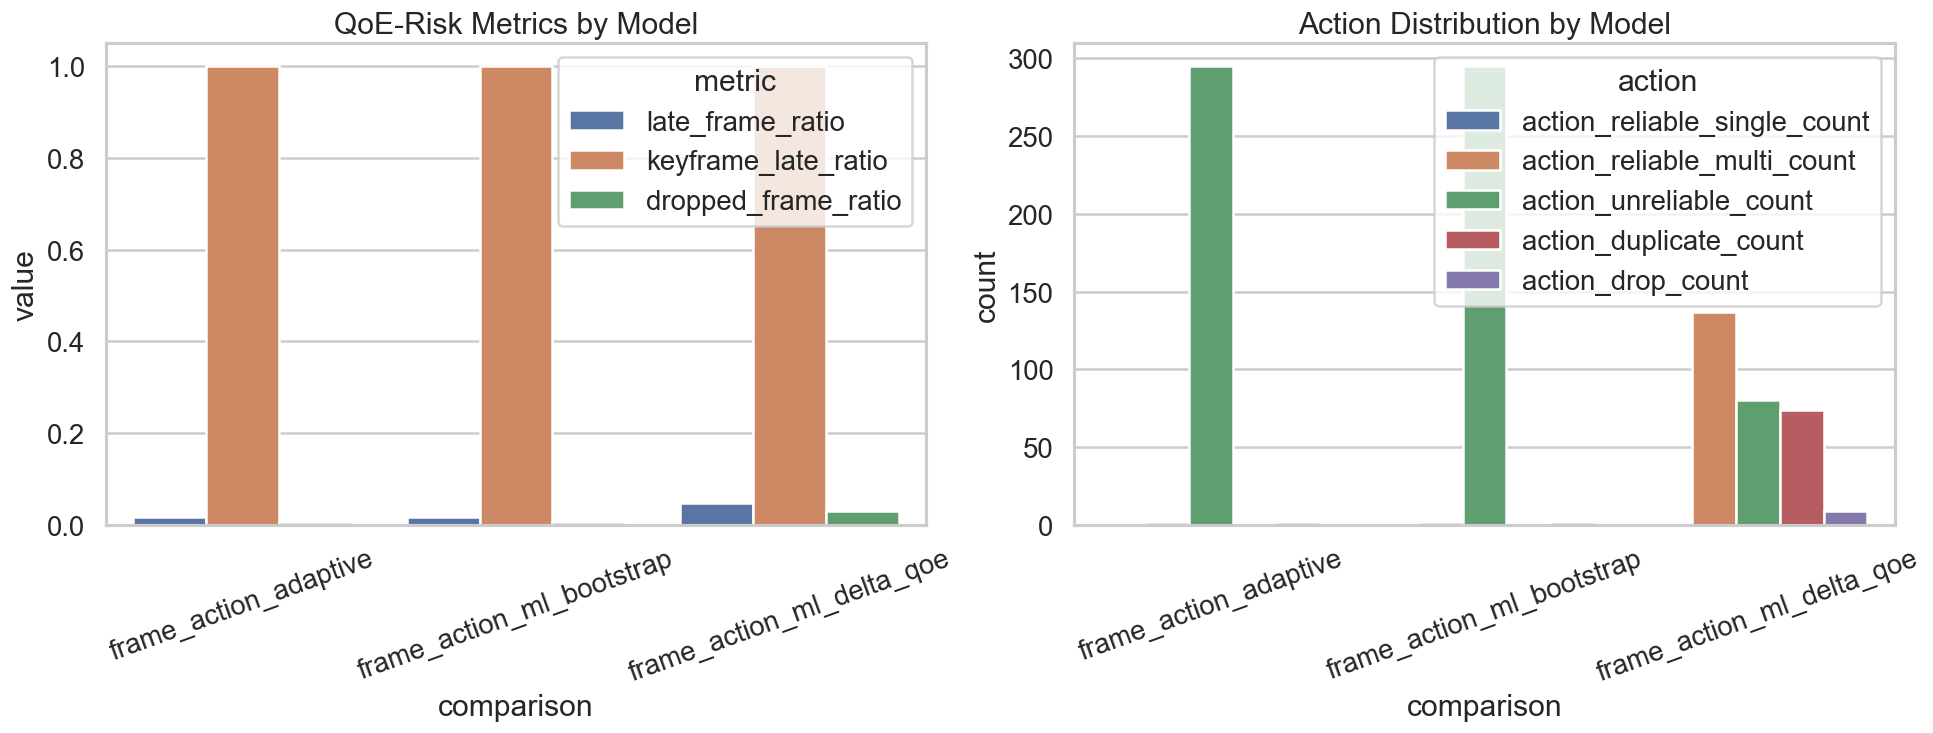

saved:
- C:\git\network\output\jupyter-notebook\assets\ml_label_model_comparison.csv
- C:\git\network\output\jupyter-notebook\assets\ml_label_model_comparison.png


,comparison,importance_scorer_type,mean_importance_score,late_frame_ratio,keyframe_late_ratio,decodable_gop_ratio,dropped_frame_ratio,action_reliable_single_count,action_reliable_multi_count,action_unreliable_count,action_duplicate_count,action_drop_count
0,frame_action_adaptive,heuristic,0.124000,0.016667,1.0,0.0,0.006667,1,2,295,0,2
1,frame_action_ml_bootstrap,ml,0.123699,0.016667,1.0,0.0,0.006667,1,2,295,0,2
2,frame_action_ml_delta_qoe,ml,0.007742,0.046667,1.0,0.0,0.030000,0,137,80,74,9


In [9]:
# cell 9 : visualize model comparison and export artifacts
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

qoe_plot_df = ml_compare_df.melt(
    id_vars=["comparison"],
    value_vars=["late_frame_ratio", "keyframe_late_ratio", "dropped_frame_ratio"],
    var_name="metric",
    value_name="value",
)
sns.barplot(data=qoe_plot_df, x="comparison", y="value", hue="metric", ax=axes[0])
axes[0].set_title("QoE-Risk Metrics by Model")
axes[0].tick_params(axis="x", rotation=20)

action_plot_df = ml_compare_df.melt(
    id_vars=["comparison"],
    value_vars=[
        "action_reliable_single_count",
        "action_reliable_multi_count",
        "action_unreliable_count",
        "action_duplicate_count",
        "action_drop_count",
    ],
    var_name="action",
    value_name="count",
)
sns.barplot(data=action_plot_df, x="comparison", y="count", hue="action", ax=axes[1])
axes[1].set_title("Action Distribution by Model")
axes[1].tick_params(axis="x", rotation=20)

compare_plot_path = ASSET_DIR / "ml_label_model_comparison.png"
fig.savefig(compare_plot_path, bbox_inches="tight")
finalize_figure(fig)

compare_csv_path = ASSET_DIR / "ml_label_model_comparison.csv"
ml_compare_df.to_csv(compare_csv_path, index=False)

print("saved:")
print(f"- {compare_csv_path}")
print(f"- {compare_plot_path}")
ml_compare_df